In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer,load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler

CLASSIFICATION WITH DEEP NEURAL NETWORK

1. Loading Breast Cancer Dataset...
   Samples: 569
   Features: 30
   Classes: 2

   Training samples: 364
   Validation samples: 91
   Test samples: 114

2. Training DNN for Binary Classification
Epoch 10/100 - Loss: 0.0866, Val Loss: 0.0830, Train Acc: 0.9863, Val Acc: 0.9670
Epoch 20/100 - Loss: 0.0639, Val Loss: 0.0657, Train Acc: 0.9945, Val Acc: 0.9890
Epoch 30/100 - Loss: 0.0511, Val Loss: 0.0613, Train Acc: 0.9973, Val Acc: 0.9890
Epoch 40/100 - Loss: 0.0434, Val Loss: 0.0550, Train Acc: 1.0000, Val Acc: 0.9780
Epoch 50/100 - Loss: 0.0388, Val Loss: 0.0517, Train Acc: 1.0000, Val Acc: 0.9780
Epoch 60/100 - Loss: 0.0361, Val Loss: 0.0510, Train Acc: 1.0000, Val Acc: 0.9780
Epoch 70/100 - Loss: 0.0338, Val Loss: 0.0513, Train Acc: 1.0000, Val Acc: 0.9780
Epoch 80/100 - Loss: 0.0320, Val Loss: 0.0516, Train Acc: 1.0000, Val Acc: 0.9780
Epoch 90/100 - Loss: 0.0302, Val Loss: 0.0527, Train Acc: 1.0000, Val Acc: 0.9670
Epoch 100/100 - Loss: 0

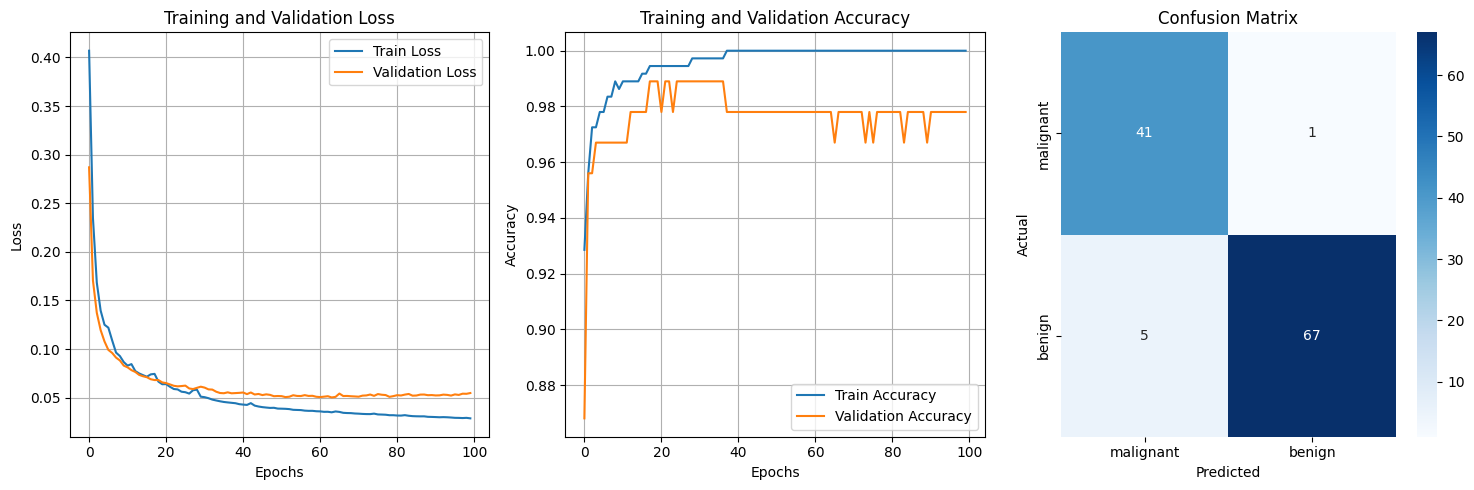


5. Model Summary

Architecture:
  Input Layer: 30 neurons
  Hidden Layer 1: 64 neurons (ReLU)
  Hidden Layer 2: 32 neurons (ReLU)
  Output Layer: 1 neuron (Sigmoid)

Total Trainable Parameters:
  Layer 1: 1,984 parameters
  Layer 2: 2,080 parameters
  Layer 3: 33 parameters
  Total: 4,097 parameters

Final Results:
  Train Loss: 0.0288
  Val Loss: 0.0548
  Train Accuracy: 100.00%
  Val Accuracy: 97.80%
  Test Accuracy: 94.74%

6. Multi-class Classification (Digits Dataset)
   Samples: 1797
   Features: 64
   Classes: 10
Epoch 10/80 - Loss: 0.1359, Val Loss: 0.2407, Train Acc: 0.9861, Val Acc: 0.9583
Epoch 20/80 - Loss: 0.0581, Val Loss: 0.1599, Train Acc: 1.0000, Val Acc: 0.9653
Epoch 30/80 - Loss: 0.0451, Val Loss: 0.1404, Train Acc: 1.0000, Val Acc: 0.9722
Epoch 40/80 - Loss: 0.0408, Val Loss: 0.1244, Train Acc: 1.0000, Val Acc: 0.9757
Epoch 50/80 - Loss: 0.0383, Val Loss: 0.1117, Train Acc: 1.0000, Val Acc: 0.9757
Epoch 60/80 - Loss: 0.0362, Val Loss: 0.1028, Train Acc: 1.0000, Val

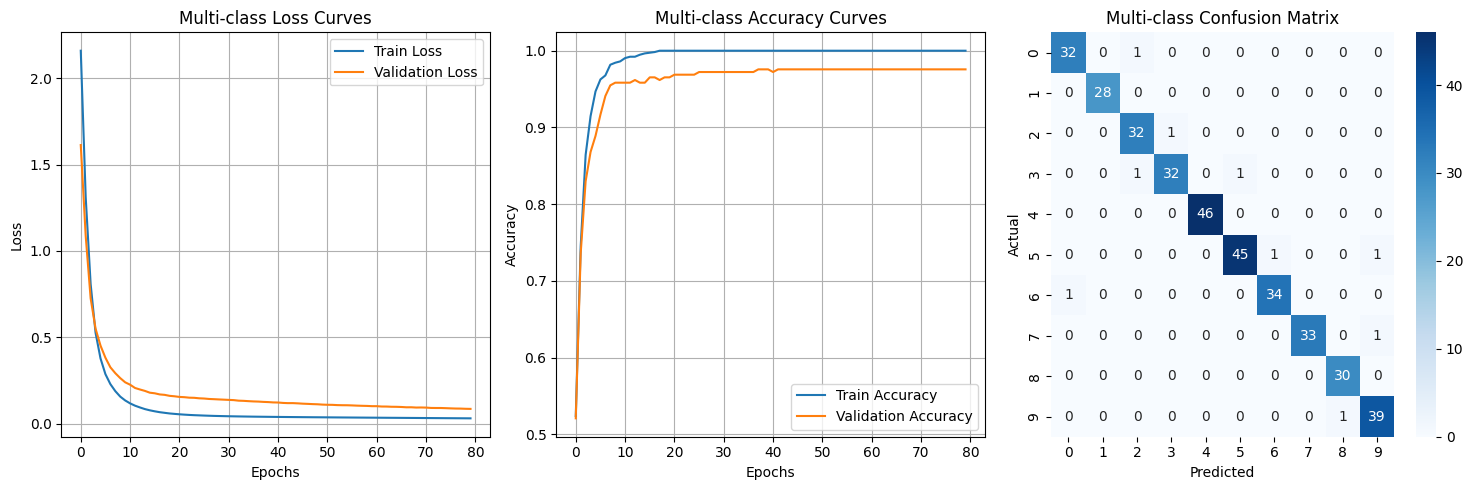

In [ ]:
class ClassificationDNN:
    def __init__(self, layer_dims, activation='relu', output_activation='sigmoid', reg_lambda=0.0):
        """
        layer_dims: List [input_dim, hidden1, hidden2, ..., output_dim]
        """
        self.layer_dims = layer_dims
        self.activation = activation
        self.output_activation = output_activation
        self.reg_lambda = reg_lambda # L2 regularization parameter
        self.L = len(layer_dims) - 1
        self.params = {}
        self.cache = {}
        self.grads = {}

        # Optimizer states for Adam
        self.optimizer_states = {
            'm_W': {}, 'm_b': {},
            'v_W': {}, 'v_b': {},
            't': 0
        }

        # He initialization
        np.random.seed(42)
        for l in range(1, self.L + 1):
            if activation == 'relu':
                scale = np.sqrt(2.0 / layer_dims[l-1])
            else:
                scale = np.sqrt(1.0 / layer_dims[l-1])

            self.params[f'W{l}'] = np.random.randn(layer_dims[l-1], layer_dims[l]) * scale
            self.params[f'b{l}'] = np.zeros((1, layer_dims[l]))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        Z = np.clip(Z, -500, 500)
        return 1 / (1 + np.exp(-Z))

    def sigmoid_derivative(self, Z):
        s = self.sigmoid(Z)
        return s * (1 - s)

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward(self, X):
        """Forward propagation"""
        A = X
        self.cache['A0'] = X

        for l in range(1, self.L + 1):
            Z = A @ self.params[f'W{l}'] + self.params[f'b{l}']
            self.cache[f'Z{l}'] = Z

            if l == self.L:  # Output layer
                if self.output_activation == 'sigmoid':
                    A = self.sigmoid(Z)
                elif self.output_activation == 'softmax':
                    A = self.softmax(Z)
                else:
                    A = Z
            else:  # Hidden layers
                if self.activation == 'relu':
                    A = self.relu(Z)
                elif self.activation == 'sigmoid':
                    A = self.sigmoid(Z)
                elif self.activation == 'tanh':
                    A = np.tanh(Z)
                else:
                    A = Z

            self.cache[f'A{l}'] = A

        return A

    def compute_loss(self, y_pred, y, loss_type='binary_cross_entropy'):
        """Compute loss with optional L2 regularization"""
        m = y.shape[0]
        eps = 1e-8

        if loss_type == 'binary_cross_entropy':
            y_pred = np.clip(y_pred, eps, 1 - eps)
            loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        elif loss_type == 'categorical_cross_entropy':
            y_pred = np.clip(y_pred, eps, 1 - eps)
            loss = -np.mean(np.sum(y * np.log(y_pred), axis=1))
        else:
            loss = np.mean((y_pred - y)**2)

        # Add L2 regularization to the loss
        l2_regularization_cost = 0
        if self.reg_lambda > 0:
            for l in range(1, self.L + 1):
                l2_regularization_cost += np.sum(np.square(self.params[f'W{l}'] ))
            loss += (self.reg_lambda / (2 * m)) * l2_regularization_cost

        return loss

    def backward(self, X, y, y_pred, loss_type='binary_cross_entropy'):
        """Backward propagation with L2 regularization"""
        m = X.shape[0]
        self.grads = {}

        # Output layer gradient
        if loss_type == 'binary_cross_entropy' and self.output_activation == 'sigmoid':
            dZ = (y_pred - y) / m
        elif loss_type == 'categorical_cross_entropy' and self.output_activation == 'softmax':
            dZ = (y_pred - y) / m
        else:
            dZ = (y_pred - y) / m

        self.grads[f'dZ{self.L}'] = dZ
        dW = self.cache[f'A{self.L-1}'].T @ dZ
        self.grads[f'dW{self.L}'] = dW + (self.reg_lambda / m) * self.params[f'W{self.L}'] # Add L2 regularization derivative
        self.grads[f'db{self.L}'] = np.sum(dZ, axis=0, keepdims=True)

        # Hidden layers
        for l in range(self.L - 1, 0, -1):
            dA = dZ @ self.params[f'W{l+1}'].T

            if self.activation == 'relu':
                dZ = dA * self.relu_derivative(self.cache[f'Z{l}'])
            elif self.activation == 'sigmoid':
                dZ = dA * self.sigmoid_derivative(self.cache[f'Z{l}'])
            elif self.activation == 'tanh':
                dZ = dA * (1 - np.tanh(self.cache[f'Z{l}'])**2)
            else:
                dZ = dA

            self.grads[f'dZ{l}'] = dZ
            dW = self.cache[f'A{l-1}'].T @ dZ
            self.grads[f'dW{l}'] = dW + (self.reg_lambda / m) * self.params[f'W{l}'] # Add L2 regularization derivative
            self.grads[f'db{l}'] = np.sum(dZ, axis=0, keepdims=True)

    def update_parameters(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        """Adam optimizer update"""
        states = self.optimizer_states
        states['t'] += 1

        for l in range(1, self.L + 1):
            dW = self.grads[f'dW{l}']
            db = self.grads[f'db{l}']

            # Update biased moments
            states['m_W'][l] = beta1 * states['m_W'].get(l, 0) + (1 - beta1) * dW
            states['m_b'][l] = beta1 * states['m_b'].get(l, 0) + (1 - beta1) * db
            states['v_W'][l] = beta2 * states['v_W'].get(l, 0) + (1 - beta2) * (dW**2)
            states['v_b'][l] = beta2 * states['v_b'].get(l, 0) + (1 - beta2) * (db**2)

            # Bias correction
            m_hat_W = states['m_W'][l] / (1 - beta1**states['t'])
            m_hat_b = states['m_b'][l] / (1 - beta1**states['t'])
            v_hat_W = states['v_W'][l] / (1 - beta2**states['t'])
            v_hat_b = states['v_b'][l] / (1 - beta2**states['t'])

            # Update weights
            self.params[f'W{l}'] -= learning_rate * m_hat_W / (np.sqrt(v_hat_W) + epsilon)
            self.params[f'b{l}'] -= learning_rate * m_hat_b / (np.sqrt(v_hat_b) + epsilon)

    def predict(self, X):
        """Make predictions"""
        probs = self.forward(X)
        if self.output_activation == 'sigmoid':
            return (probs > 0.5).astype(int), probs
        elif self.output_activation == 'softmax':
            return np.argmax(probs, axis=1), probs
        else:
            return probs, probs

    def train(self, X_train, y_train, X_val, y_val, epochs=100, batch_size=32,
              learning_rate=0.001, loss_type='binary_cross_entropy', verbose=True):
        """Train the network"""
        m = X_train.shape[0]
        train_losses = []
        val_losses = []
        train_accs = []
        val_accs = []

        # For accuracy calculation - convert one-hot to labels if needed
        if len(y_train.shape) > 1 and y_train.shape[1] > 1:
            y_train_labels = np.argmax(y_train, axis=1)
            y_val_labels = np.argmax(y_val, axis=1)
        else:
            y_train_labels = y_train.flatten()
            y_val_labels = y_val.flatten()

        for epoch in range(epochs):
            # Shuffle data
            indices = np.random.permutation(m)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            epoch_loss = 0
            num_batches = 0

            # Mini-batch training
            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                y_pred = self.forward(X_batch)
                self.backward(X_batch, y_batch, y_pred, loss_type)
                self.update_parameters(learning_rate)

                batch_loss = self.compute_loss(y_pred, y_batch, loss_type)
                epoch_loss += batch_loss
                num_batches += 1

            # Calculate metrics
            avg_loss = epoch_loss / num_batches
            train_losses.append(avg_loss)

            # Validation
            y_val_pred, _ = self.predict(X_val)
            val_loss = self.compute_loss(self.forward(X_val), y_val, loss_type)
            val_losses.append(val_loss)

            # Training accuracy
            y_train_pred, _ = self.predict(X_train)
            train_accs.append(accuracy_score(y_train_labels, y_train_pred))

            # Validation accuracy
            val_accs.append(accuracy_score(y_val_labels, y_val_pred))

            if verbose and (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, "
                      f"Val Loss: {val_loss:.4f}, Train Acc: {train_accs[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

        return train_losses, val_losses, train_accs, val_accs


# ============================================
# 2. Load and Prepare Dataset
# ============================================


print("="*60)
print("CLASSIFICATION WITH DEEP NEURAL NETWORK")
print("="*60)


# Binary Classification: Breast Cancer Dataset
print("\n1. Loading Breast Cancer Dataset...")
data = load_breast_cancer()
X, y = data.data, data.target.reshape(-1, 1)


print(f"   Samples: {X.shape[0]}")
print(f"   Features: {X.shape[1]}")
print(f"   Classes: {len(np.unique(y))}")


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Split train into train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


print(f"\n   Training samples: {X_train.shape[0]}")
print(f"   Validation samples: {X_val.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")


# ============================================
# 3. Train DNN for Binary Classification
# ============================================


print("\n" + "="*60)
print("2. Training DNN for Binary Classification")
print("="*60)


# Architecture: 30 inputs -> 64 -> 32 -> 1 output (2 hidden layers)
layer_dims = [X_train.shape[1], 64, 32, 1]


model = ClassificationDNN(
    layer_dims=layer_dims,
    activation='relu',
    output_activation='sigmoid',
    reg_lambda=0.01 # Example: add L2 regularization
)


# Train
train_loss, val_loss, train_acc, val_acc = model.train(
    X_train, y_train, X_val, y_val,
    epochs=100,
    batch_size=32,
    learning_rate=0.001,
    loss_type='binary_cross_entropy',
    verbose=True
)


# ============================================
# 4. Evaluate on Test Set
# ============================================


print("\n" + "="*60)
print("3. Model Evaluation")
print("="*60)


# Test predictions
y_test_pred, y_test_probs = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)


print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=data.target_names))


# ============================================
# 5. Visualizations
# ============================================


print("\n" + "="*60)
print("4. Visualizations")
print("="*60)


plt.figure(figsize=(15, 5))


# Loss curves
plt.subplot(1, 3, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)


# Accuracy curves
plt.subplot(1, 3, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)


# Confusion Matrix
plt.subplot(1, 3, 3)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.tight_layout()
plt.show()


# ============================================
# 6. Model Summary
# ============================================


print("\n" + "="*60)
print("5. Model Summary")
print("="*60)


print("\nArchitecture:")
for i, dim in enumerate(layer_dims):
    if i == 0:
        print(f"  Input Layer: {dim} neurons")
    elif i == len(layer_dims) - 1:
        print(f"  Output Layer: {dim} neuron (Sigmoid)")
    else:
        print(f"  Hidden Layer {i}: {dim} neurons (ReLU)")


print(f"\nTotal Trainable Parameters:")
total_params = 0
for l in range(1, len(layer_dims)):
    params = layer_dims[l-1] * layer_dims[l] + layer_dims[l]
    total_params += params
    print(f"  Layer {l}: {params:,} parameters")
print(f"  Total: {total_params:,} parameters")


print(f"\nFinal Results:")
print(f"  Train Loss: {train_loss[-1]:.4f}")
print(f"  Val Loss: {val_loss[-1]:.4f}")
print(f"  Train Accuracy: {train_acc[-1]*100:.2f}%")
print(f"  Val Accuracy: {val_acc[-1]*100:.2f}%")
print(f"  Test Accuracy: {test_accuracy*100:.2f}%")


# ============================================
# 7. Multi-class Classification Example
# ============================================


print("\n" + "="*60)
print("6. Multi-class Classification (Digits Dataset)")
print("="*60)


# Load digits dataset
digits = load_digits()
X_digits, y_digits = digits.data, digits.target


print(f"   Samples: {X_digits.shape[0]}")
print(f"   Features: {X_digits.shape[1]}")
print(f"   Classes: {len(np.unique(y_digits))}")


# One-hot encode for multi-class
y_onehot = np.eye(10)[y_digits]


X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_onehot, test_size=0.2, random_state=42
)


scaler_d = StandardScaler()
X_train_d = scaler_d.fit_transform(X_train_d)
X_test_d = scaler_d.transform(X_test_d)


X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_train_d, y_train_d, test_size=0.2, random_state=42
)


# Multi-class architecture
layer_dims_multi = [X_train_d.shape[1], 64, 32, 10]


model_multi = ClassificationDNN(
    layer_dims=layer_dims_multi,
    activation='relu',
    output_activation='softmax',
    reg_lambda=0.01 # Example: add L2 regularization
)


# Train
train_loss_m, val_loss_m, train_acc_m, val_acc_m = model_multi.train(
    X_train_d, y_train_d, X_val_d, y_val_d,
    epochs=80,
    batch_size=32,
    learning_rate=0.001,
    loss_type='categorical_cross_entropy',
    verbose=True
)


# Test
y_test_pred_m, _ = model_multi.predict(X_test_d)
y_test_true_m = np.argmax(y_test_d, axis=1)
test_acc_m = accuracy_score(y_test_true_m, y_test_pred_m)


print(f"\nMulti-class Test Accuracy: {test_acc_m*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test_true_m, y_test_pred_m))


# ============================================
# 8. Multi-class Visualizations
# ============================================


plt.figure(figsize=(15, 5))


# Loss curves
plt.subplot(1, 3, 1)
plt.plot(train_loss_m, label='Train Loss')
plt.plot(val_loss_m, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Multi-class Loss Curves')
plt.legend()
plt.grid(True)


# Accuracy curves
plt.subplot(1, 3, 2)
plt.plot(train_acc_m, label='Train Accuracy')
plt.plot(val_acc_m, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Multi-class Accuracy Curves')
plt.legend()
plt.grid(True)


# Confusion Matrix
plt.subplot(1, 3, 3)
cm_m = confusion_matrix(y_test_true_m, y_test_pred_m)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues')
plt.title('Multi-class Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.tight_layout()
plt.show()